<a href="https://colab.research.google.com/github/CarlosBaztan/Clases-Python-UNIR/blob/main/Examen%20Gesti%C3%B3n%20de%20Proyectos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EXAMEN GESTIÓN DE PROYECTOS PYTHON

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv('Mall_Customers.csv')

In [6]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [7]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [11]:
# Cargar
import pandas as pd
df = pd.read_csv('Mall_Customers.csv')
df = df.rename(columns={'CustomerID':'IDCliente','Gender':'Sexo','Age':'Edad',
                         'Annual Income (k$)':'AnnualIncome','Spending Score (1-100)':'SpendingScore'})
df['Sexo'] = df['Sexo'].map({'Male':1,'Female':0})

In [10]:
df.isnull().sum()        # confirma 0 nulos
df.duplicated().sum()    # confirma 0 duplicados

np.int64(0)

In [23]:
# Selección de variables y escalado
from sklearn.preprocessing import StandardScaler

X = df[['AnnualIncome', 'SpendingScore']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [24]:
# Método del codo y Silhouette
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inercias = []
silhouettes = []
rango_k = range(2, 11)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = kmeans.fit_predict(X_scaled)
    inercias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, etiquetas))

resultados_k = pd.DataFrame({"K": list(rango_k), "Inercia": inercias, "Silhouette": silhouettes})
print(resultados_k)

    K     Inercia  Silhouette
0   2  269.691012    0.321271
1   3  157.704008    0.466585
2   4  108.921317    0.493907
3   5   65.568408    0.554657
4   6   55.057348    0.539880
5   7   44.864756    0.528149
6   8   37.228188    0.455215
7   9   32.392268    0.457085
8  10   29.981898    0.443171


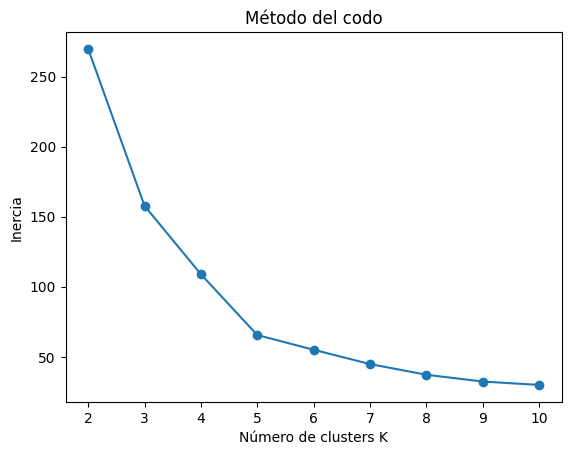

In [25]:
# Gráfico del codo
import matplotlib.pyplot as plt

plt.plot(rango_k, inercias, marker="o")
plt.xlabel("Número de clusters K")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()

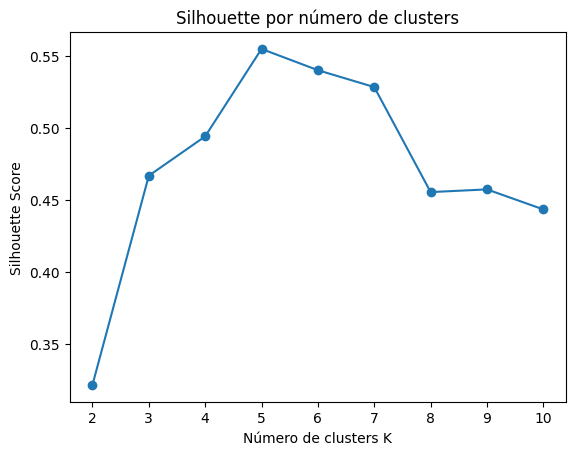

In [26]:
# Gráfico Silhouette
plt.plot(rango_k, silhouettes, marker="o")
plt.xlabel("Número de clusters K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette por número de clusters")
plt.show()


In [21]:
# Modelo final
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

In [22]:
# Interpretación
print(df.groupby('cluster')[['AnnualIncome','SpendingScore']].mean().round(1))
print(df['cluster'].value_counts())

         AnnualIncome  SpendingScore
cluster                             
0                55.3           49.5
1                86.5           82.1
2                25.7           79.4
3                88.2           17.1
4                26.3           20.9
cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64
